<a href="https://colab.research.google.com/github/jangirsachin9619-cpu/ML-a2-Global-Pollution-Analysis-and-Energy-Recovery/blob/main/mla2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
path=('/content/drive/MyDrive/Global_Pollution_Analysis.csv')
df=pd.read_csv(path)
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float6

In [23]:
df.isnull().sum()

,0
Country,0
Year,0
Air_Pollution_Index,0
Water_Pollution_Index,0
Soil_Pollution_Index,0
Industrial_Waste (in tons),0
Energy_Recovered (in GWh),0
CO2_Emissions (in MT),0
Renewable_Energy (%),0
Plastic_Waste_Produced (in tons),0


In [58]:
df.fillna(df.mean(), inplace=True)

In [29]:
fill_null_values = df.select_dtypes(include=['number']).mean()

In [57]:
df_raw = df_raw.sort_values(by=['Country', 'Year'])
pollution_columns = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'CO2_Emissions (in MT)', 'Industrial_Waste (in tons)']

for col in pollution_columns:
    df_raw[f'{col}_YoY_Growth'] = df_raw.groupby('Country')[col].pct_change() * 100


print(df_raw.head())


         Country       Year  Air_Pollution_Index  Water_Pollution_Index  \
120  Afghanistan 2002-01-01               202.26                 138.90   
188  Afghanistan 2006-01-01               105.10                  82.34   
78       Albania 2006-01-01               152.21                 110.41   
90       Andorra 2005-01-01               189.39                  46.83   
24        Angola 2016-01-01               221.40                 192.86   

     Soil_Pollution_Index  Industrial_Waste (in tons)  \
120                 45.10                    43576.51   
188                 84.06                    20688.64   
78                  86.94                    93094.36   
90                  91.86                    33356.33   
24                  36.32                    33021.64   

     Energy_Recovered (in GWh)  CO2_Emissions (in MT)  Renewable_Energy (%)  \
120                     150.10                   9.58                 34.61   
188                     146.28                  

In [55]:
growth_columns = [f'{col}_YoY_Growth' for col in pollution_columns]
df_reloaded = pd.merge(
    df_reloaded,
    df_raw[['Country', 'Year'] + growth_columns],
    on=['Country', 'Year'],
    how='left'
)

print(df_reloaded.head())

        Country       Year  Air_Pollution_Index  Water_Pollution_Index  \
0       Hungary 2005-01-01             0.898042               0.553778   
1     Singapore 2001-01-01             0.147062               0.173673   
2       Romania 2016-01-01             0.166727               0.310542   
3  Cook Islands 2018-01-01             0.929982               0.214222   
4      Djibouti 2008-01-01             0.520331               0.573161   

   Soil_Pollution_Index  Industrial_Waste (in tons)  \
0              0.295481                    94802.83   
1              0.768178                    56283.92   
2              0.800768                    56256.02   
3              0.596973                    74864.73   
4              0.799537                    76862.06   

   Energy_Recovered (in GWh)  CO2_Emissions (in MT)  Renewable_Energy (%)  \
0                     158.14                   5.30                 41.11   
1                     498.04                   6.34                 36

In [56]:
df_reloaded['Year'] = pd.to_datetime(df_reloaded['Year'], format='%Y')

growth_columns = [f'{col}_YoY_Growth' for col in pollution_columns]
df_reloaded = pd.merge(
    df_reloaded,
    df_raw[['Country', 'Year'] + growth_columns],
    on=['Country', 'Year'],
    how='left'
)

print(df_reloaded.head())

        Country       Year  Air_Pollution_Index  Water_Pollution_Index  \
0       Hungary 2005-01-01             0.898042               0.553778   
1     Singapore 2001-01-01             0.147062               0.173673   
2       Romania 2016-01-01             0.166727               0.310542   
3  Cook Islands 2018-01-01             0.929982               0.214222   
4      Djibouti 2008-01-01             0.520331               0.573161   

   Soil_Pollution_Index  Industrial_Waste (in tons)  \
0              0.295481                    94802.83   
1              0.768178                    56283.92   
2              0.800768                    56256.02   
3              0.596973                    74864.73   
4              0.799537                    76862.06   

   Energy_Recovered (in GWh)  CO2_Emissions (in MT)  Renewable_Energy (%)  \
0                     158.14                   5.30                 41.11   
1                     498.04                   6.34                 36

In [33]:
from sklearn.preprocessing import MinMaxScaler
column_to_standardize = ['Air_Pollution_Index','Water_Pollution_Index','Soil_Pollution_Index']
scaler=MinMaxScaler()
df[column_to_standardize] = scaler.fit_transform(df[column_to_standardize])
print(df.head())

        Country  Year  Air_Pollution_Index  Water_Pollution_Index  \
0       Hungary  2005             0.898042               0.553778   
1     Singapore  2001             0.147062               0.173673   
2       Romania  2016             0.166727               0.310542   
3  Cook Islands  2018             0.929982               0.214222   
4      Djibouti  2008             0.520331               0.573161   

   Soil_Pollution_Index  Industrial_Waste (in tons)  \
0              0.295481                    94802.83   
1              0.768178                    56283.92   
2              0.800768                    56256.02   
3              0.596973                    74864.73   
4              0.799537                    76862.06   

   Energy_Recovered (in GWh)  CO2_Emissions (in MT)  Renewable_Energy (%)  \
0                     158.14                   5.30                 41.11   
1                     498.04                   6.34                 36.44   
2                     4

In [34]:
df_encoded = pd.get_dummies(df['Country'], prefix='Country', drop_first=True)
df = pd.concat([df, df_encoded], axis=1)
df.drop('Country', axis=1, inplace=True)
print(df.head())

   Year  Air_Pollution_Index  Water_Pollution_Index  Soil_Pollution_Index  \
0  2005             0.898042               0.553778              0.295481   
1  2001             0.147062               0.173673              0.768178   
2  2016             0.166727               0.310542              0.800768   
3  2018             0.929982               0.214222              0.596973   
4  2008             0.520331               0.573161              0.799537   

   Industrial_Waste (in tons)  Energy_Recovered (in GWh)  \
0                    94802.83                     158.14   
1                    56283.92                     498.04   
2                    56256.02                     489.51   
3                    74864.73                     145.18   
4                    76862.06                      40.38   

   CO2_Emissions (in MT)  Renewable_Energy (%)  \
0                   5.30                 41.11   
1                   6.34                 36.44   
2                  49.69  

In [35]:
numerical_columns = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']
print('Mean:')
print(df[numerical_columns].mean())
print('\nStandard Deviation:')
print(df[numerical_columns].std())
print('\nmode:')
print(df[numerical_columns].mode())
print('\nmedian:')
print(df[numerical_columns].median())
print('\nQuantiles:')
print(df[numerical_columns].quantile())
print('\nVariance:')
print(df[numerical_columns].var())

Mean:
Air_Pollution_Index      0.526255
Water_Pollution_Index    0.499067
Soil_Pollution_Index     0.473193
dtype: float64

Standard Deviation:
Air_Pollution_Index      0.270839
Water_Pollution_Index    0.282900
Soil_Pollution_Index     0.287462
dtype: float64

mode:
     Air_Pollution_Index  Water_Pollution_Index  Soil_Pollution_Index
0               0.259035               0.000000              0.000000
1               0.408076               0.001784              0.004490
2                    NaN               0.003151              0.004925
3                    NaN               0.003924              0.006590
4                    NaN               0.026220              0.006952
..                   ...                    ...                   ...
195                  NaN               0.961591              0.977549
196                  NaN               0.962126              0.978491
197                  NaN               0.983114              0.979794
198                  NaN        

In [36]:
numerical_features_to_describe = ['CO2_Emissions (in MT)', 'Industrial_Waste (in tons)']

print('Descriptive Statistics for CO2_Emissions (in MT) and Industrial_Waste (in tons):')
print('\nMean:')
print(df[numerical_features_to_describe].mean())
print('\nStandard Deviation:')
print(df[numerical_features_to_describe].std())
print('\nMode:')
print(df[numerical_features_to_describe].mode())
print('\nMedian:')
print(df[numerical_features_to_describe].median())
print('\nQuantiles:')
print(df[numerical_features_to_describe].quantile())
print('\nVariance:')
print(df[numerical_features_to_describe].var())

Descriptive Statistics for CO2_Emissions (in MT) and Industrial_Waste (in tons):

Mean:
CO2_Emissions (in MT)            24.8781
Industrial_Waste (in tons)    52891.6815
dtype: float64

Standard Deviation:
CO2_Emissions (in MT)            14.470892
Industrial_Waste (in tons)    27224.491690
dtype: float64

Mode:
     CO2_Emissions (in MT)  Industrial_Waste (in tons)
0                     5.30                     1019.37
1                    11.28                     1650.31
2                    17.33                     2613.94
3                    38.16                     2818.85
4                      NaN                     4431.63
..                     ...                         ...
195                    NaN                    98455.05
196                    NaN                    99237.91
197                    NaN                    99688.18
198                    NaN                    99710.80
199                    NaN                    99739.36

[200 rows x 2 columns]

M

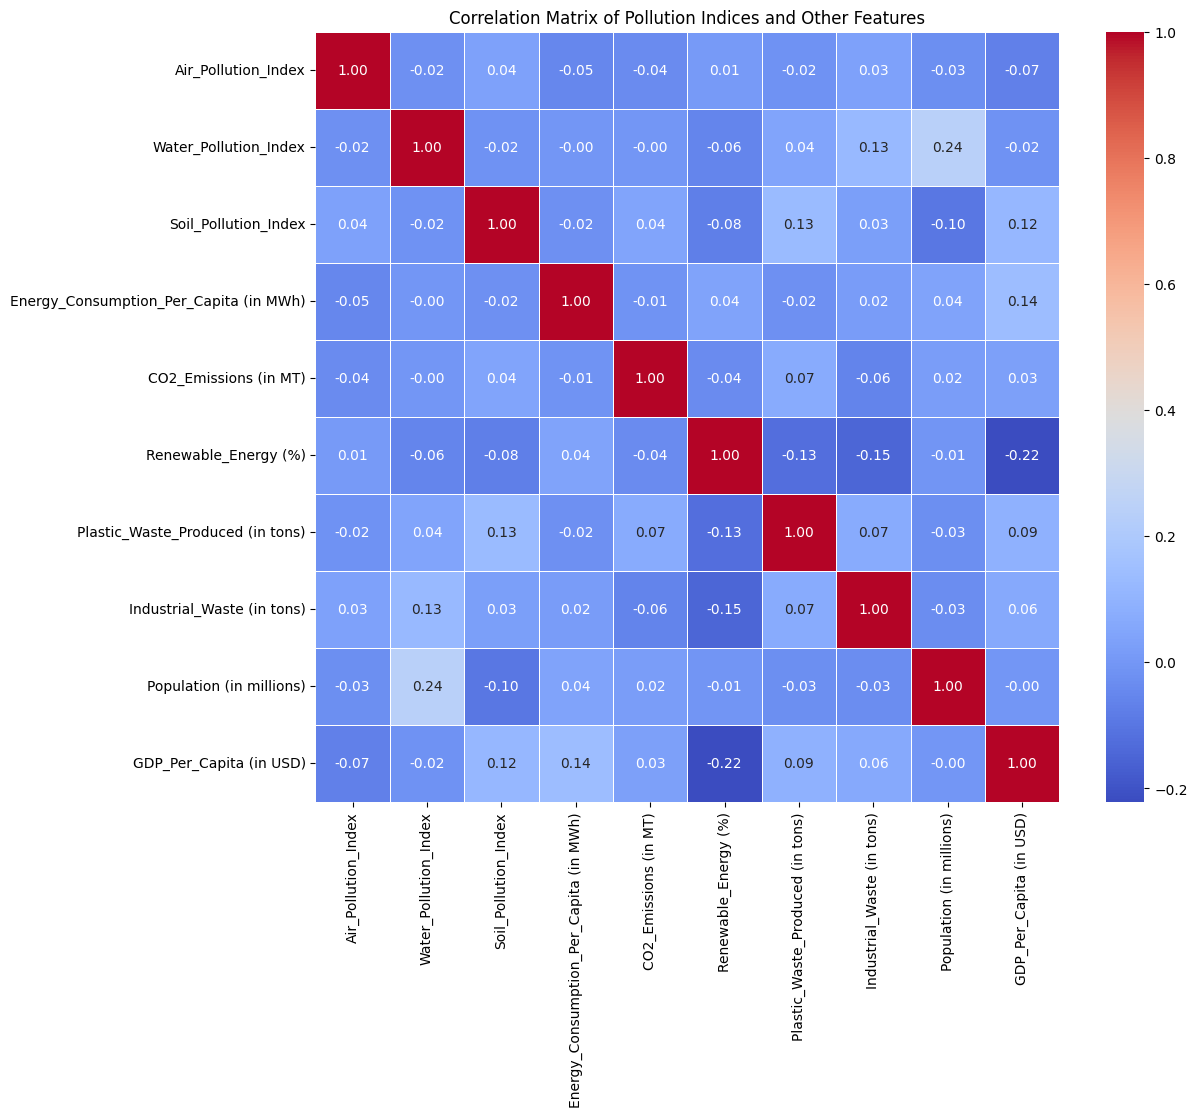

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
correlation_columns = [
    'Air_Pollution_Index',
    'Water_Pollution_Index',
    'Soil_Pollution_Index',
    'Energy_Consumption_Per_Capita (in MWh)',
    'CO2_Emissions (in MT)',
    'Renewable_Energy (%)',
    'Plastic_Waste_Produced (in tons)',
    'Industrial_Waste (in tons)',
    'Population (in millions)',
    'GDP_Per_Capita (in USD)'
]
correlation_matrix = df[correlation_columns].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Pollution Indices and Other Features')
plt.show()

In [38]:
df_reloaded = pd.read_csv(path)
print(df_reloaded.head())

        Country  Year  Air_Pollution_Index  Water_Pollution_Index  \
0       Hungary  2005               272.70                 124.27   
1     Singapore  2001                86.72                  60.34   
2       Romania  2016                91.59                  83.36   
3  Cook Islands  2018               280.61                  67.16   
4      Djibouti  2008               179.16                 127.53   

   Soil_Pollution_Index  Industrial_Waste (in tons)  \
0                 51.95                    94802.83   
1                117.22                    56283.92   
2                121.72                    56256.02   
3                 93.58                    74864.73   
4                121.55                    76862.06   

   Energy_Recovered (in GWh)  CO2_Emissions (in MT)  Renewable_Energy (%)  \
0                     158.14                   5.30                 41.11   
1                     498.04                   6.34                 36.44   
2                     4

In [42]:
from sklearn.preprocessing import MinMaxScaler

columns_to_scale = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']
scaler = MinMaxScaler()
df_reloaded[columns_to_scale] = scaler.fit_transform(df_reloaded[columns_to_scale])

print(df_reloaded.head())

        Country       Year  Air_Pollution_Index  Water_Pollution_Index  \
0       Hungary 2005-01-01             0.898042               0.553778   
1     Singapore 2001-01-01             0.147062               0.173673   
2       Romania 2016-01-01             0.166727               0.310542   
3  Cook Islands 2018-01-01             0.929982               0.214222   
4      Djibouti 2008-01-01             0.520331               0.573161   

   Soil_Pollution_Index  Industrial_Waste (in tons)  \
0              0.295481                    94802.83   
1              0.768178                    56283.92   
2              0.800768                    56256.02   
3              0.596973                    74864.73   
4              0.799537                    76862.06   

   Energy_Recovered (in GWh)  CO2_Emissions (in MT)  Renewable_Energy (%)  \
0                     158.14                   5.30                 41.11   
1                     498.04                   6.34                 36

In [43]:
mean_air_pollution_by_country = df_reloaded.groupby('Country')['Air_Pollution_Index'].mean().sort_values(ascending=False)
print(mean_air_pollution_by_country.head())

Country
Equatorial Guinea                       1.000000
Saint Barthelemy                        0.996689
French Southern Territories             0.983687
Congo                                   0.977226
United States Minor Outlying Islands    0.971452
Name: Air_Pollution_Index, dtype: float64


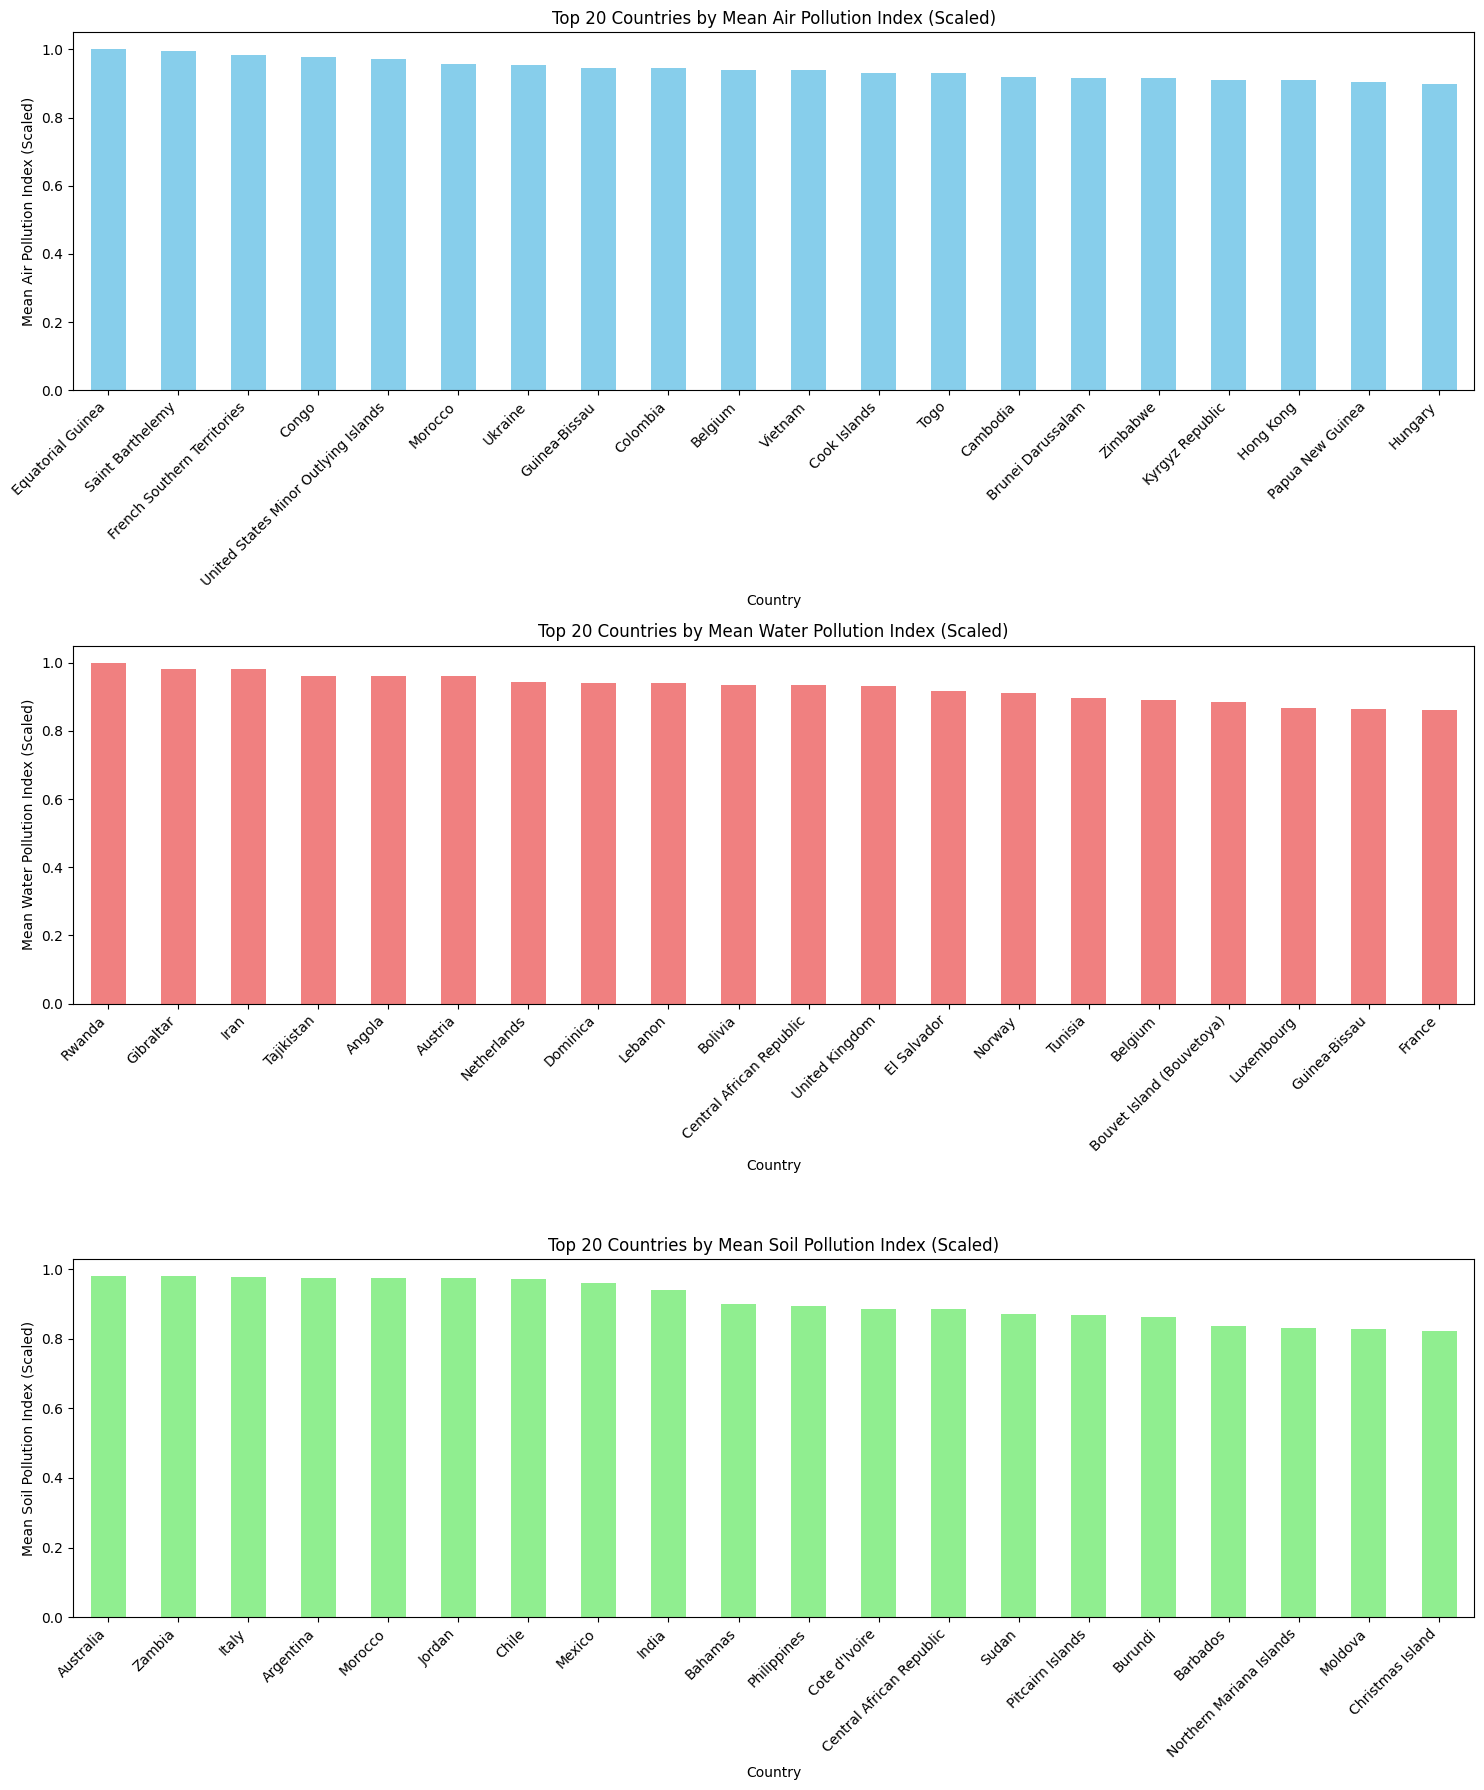

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

mean_air_pollution_by_country = df_reloaded.groupby('Country')['Air_Pollution_Index'].mean().sort_values(ascending=False)
mean_water_pollution_by_country = df_reloaded.groupby('Country')['Water_Pollution_Index'].mean().sort_values(ascending=False)
mean_soil_pollution_by_country = df_reloaded.groupby('Country')['Soil_Pollution_Index'].mean().sort_values(ascending=False)

plt.figure(figsize=(15, 18))

plt.subplot(3, 1, 1)
mean_air_pollution_by_country.head(20).plot(kind='bar', color='skyblue')
plt.title('Top 20 Countries by Mean Air Pollution Index (Scaled)')
plt.xlabel('Country')
plt.ylabel('Mean Air Pollution Index (Scaled)')
plt.xticks(rotation=45, ha='right')

plt.subplot(3, 1, 2)
mean_water_pollution_by_country.head(20).plot(kind='bar', color='lightcoral')
plt.title('Top 20 Countries by Mean Water Pollution Index (Scaled)')
plt.xlabel('Country')
plt.ylabel('Mean Water Pollution Index (Scaled)')
plt.xticks(rotation=45, ha='right')

plt.subplot(3, 1, 3)
mean_soil_pollution_by_country.head(20).plot(kind='bar', color='lightgreen')
plt.title('Top 20 Countries by Mean Soil Pollution Index (Scaled)')
plt.xlabel('Country')
plt.ylabel('Mean Soil Pollution Index (Scaled)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

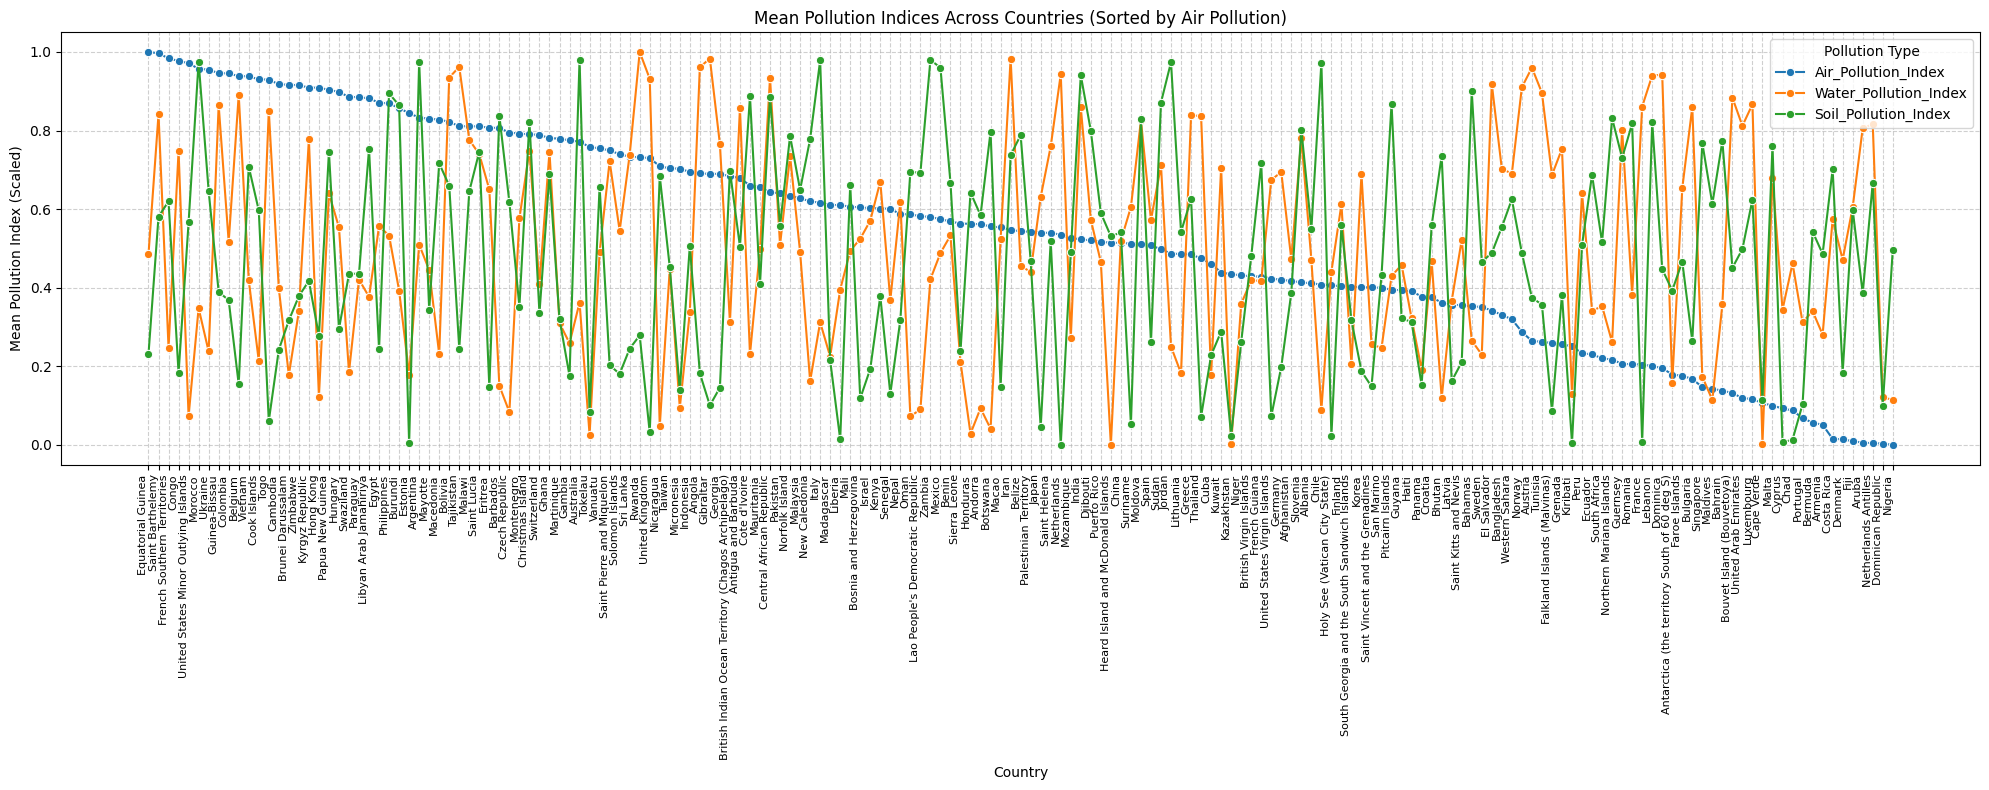

In [45]:

mean_pollution_by_country = df_reloaded.groupby('Country')[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']].mean().reset_index()

mean_pollution_by_country_sorted = mean_pollution_by_country.sort_values(by='Air_Pollution_Index', ascending=False)

mean_pollution_melted = mean_pollution_by_country_sorted.melt(
    id_vars=['Country'],
    value_vars=['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index'],
    var_name='Pollution Type',
    value_name='Mean Pollution Index'
)

plt.figure(figsize=(20, 8))
sns.lineplot(data=mean_pollution_melted, x='Country', y='Mean Pollution Index', hue='Pollution Type', marker='o')
plt.title('Mean Pollution Indices Across Countries (Sorted by Air Pollution)')
plt.xlabel('Country')
plt.ylabel('Mean Pollution Index (Scaled)')
plt.xticks(rotation=90, ha='right', fontsize=8) # Rotate labels for readability
plt.legend(title='Pollution Type')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

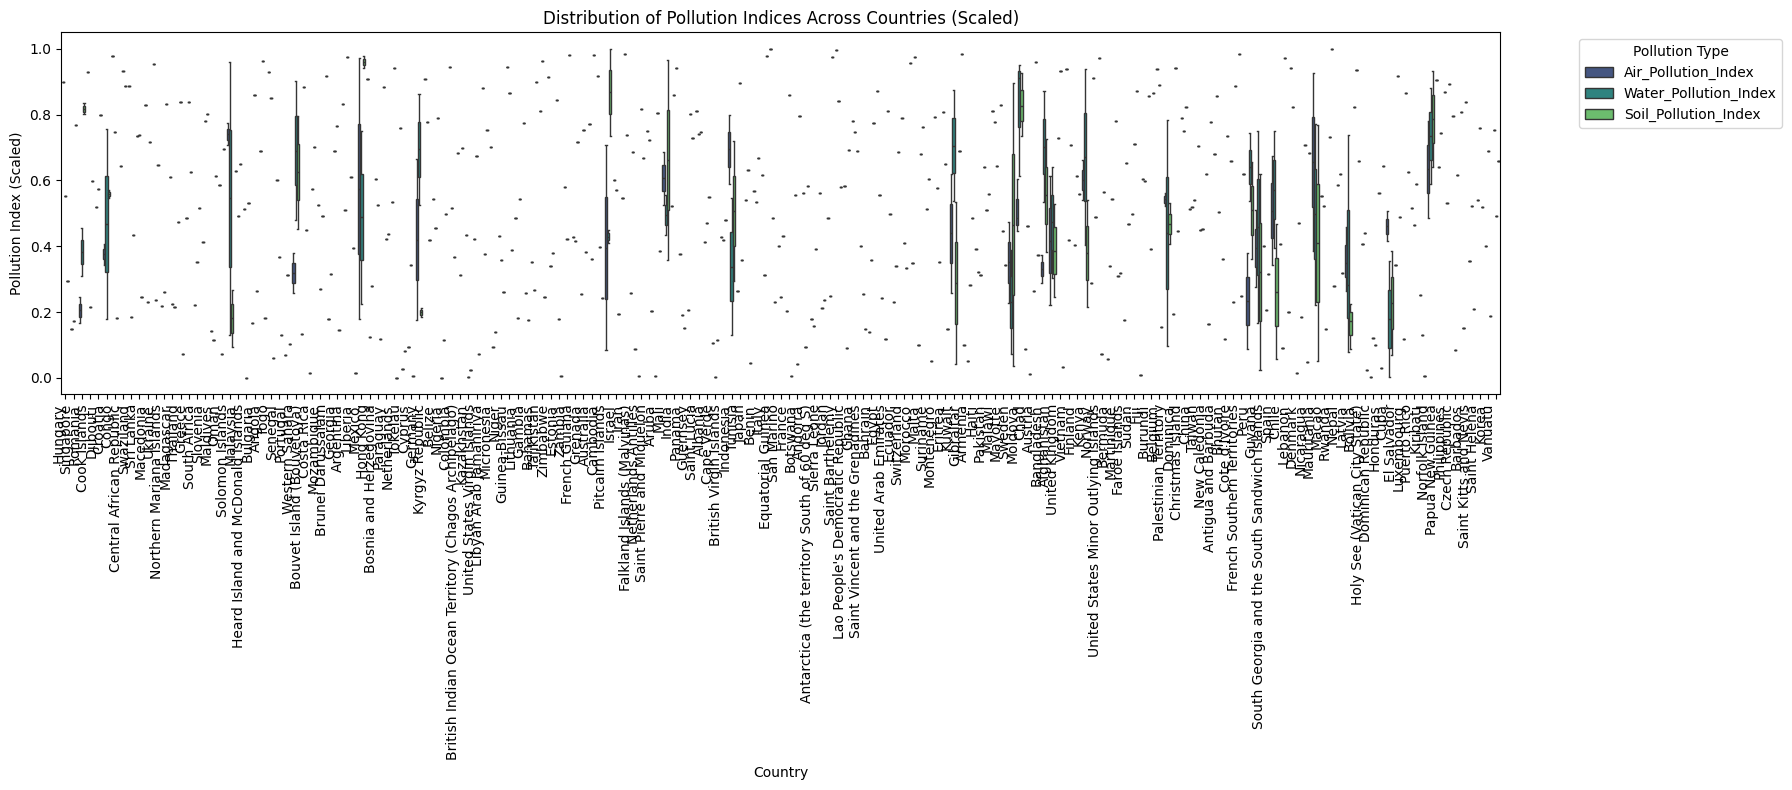

In [46]:
pollution_indices = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']

df_melted = df_reloaded.melt(id_vars=['Country'], value_vars=pollution_indices, var_name='Pollution Type', value_name='Pollution Index')

plt.figure(figsize=(18, 8))
sns.boxplot(data=df_melted, x='Country', y='Pollution Index', hue='Pollution Type', palette='viridis')
plt.title('Distribution of Pollution Indices Across Countries (Scaled)')
plt.xlabel('Country')
plt.ylabel('Pollution Index (Scaled)')
plt.xticks(rotation=90, ha='right')
plt.legend(title='Pollution Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

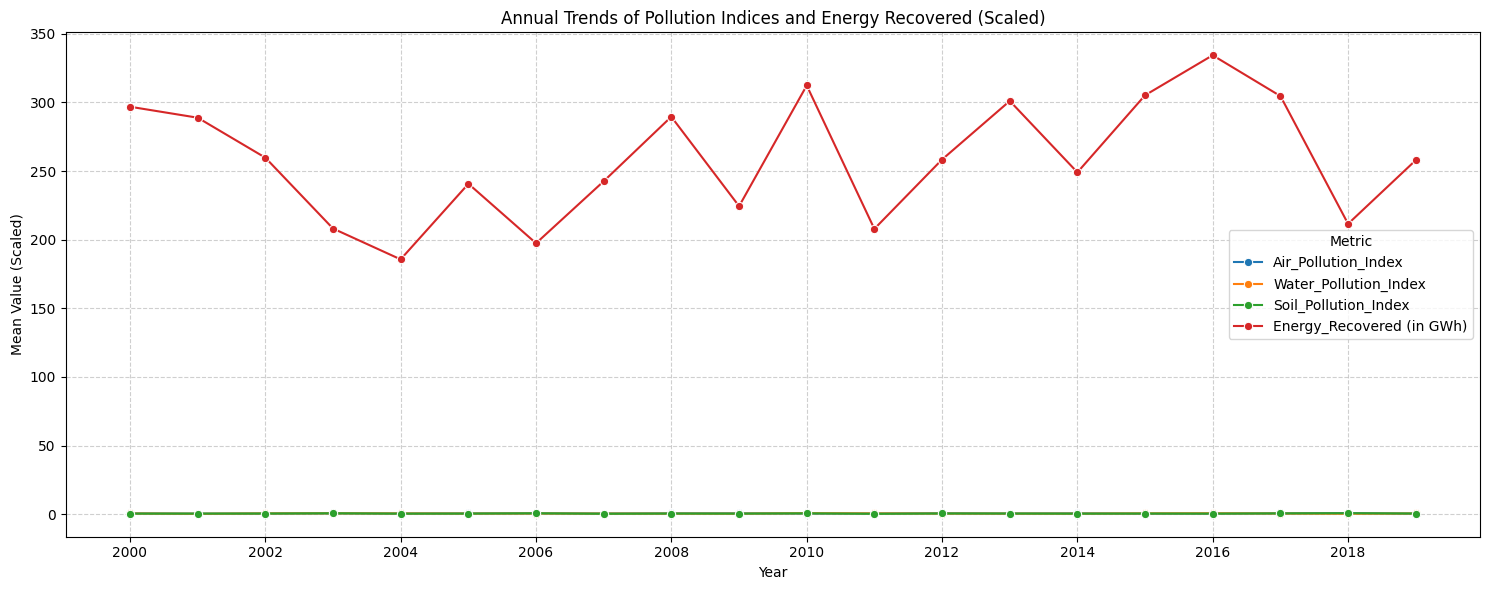

In [48]:
annual_pollution_trends = df_reloaded.groupby('Year')[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'Energy_Recovered (in GWh)']].mean().reset_index()

plt.figure(figsize=(15, 6))
sns.lineplot(data=annual_pollution_trends.melt(id_vars=['Year'], var_name='Metric', value_name='Mean Value'), x='Year', y='Mean Value', hue='Metric', marker='o')
plt.title('Annual Trends of Pollution Indices and Energy Recovered (Scaled)')
plt.xlabel('Year')
plt.ylabel('Mean Value (Scaled)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

In [49]:
print('Head of Energy_Consumption_Per_Capita (in MWh) column:')
print(df_reloaded['Energy_Consumption_Per_Capita (in MWh)'].head())

print('\nDescriptive Statistics for Energy_Consumption_Per_Capita (in MWh):')
print(df_reloaded['Energy_Consumption_Per_Capita (in MWh)'].describe())

Head of Energy_Consumption_Per_Capita (in MWh) column:
0    12.56
1     5.23
2    13.15
3     0.78
4    12.84
Name: Energy_Consumption_Per_Capita (in MWh), dtype: float64

Descriptive Statistics for Energy_Consumption_Per_Capita (in MWh):
count    202.00000
mean       9.39302
std        5.58119
min        0.53000
25%        4.56750
50%        9.22500
75%       13.98500
max       19.98000
Name: Energy_Consumption_Per_Capita (in MWh), dtype: float64


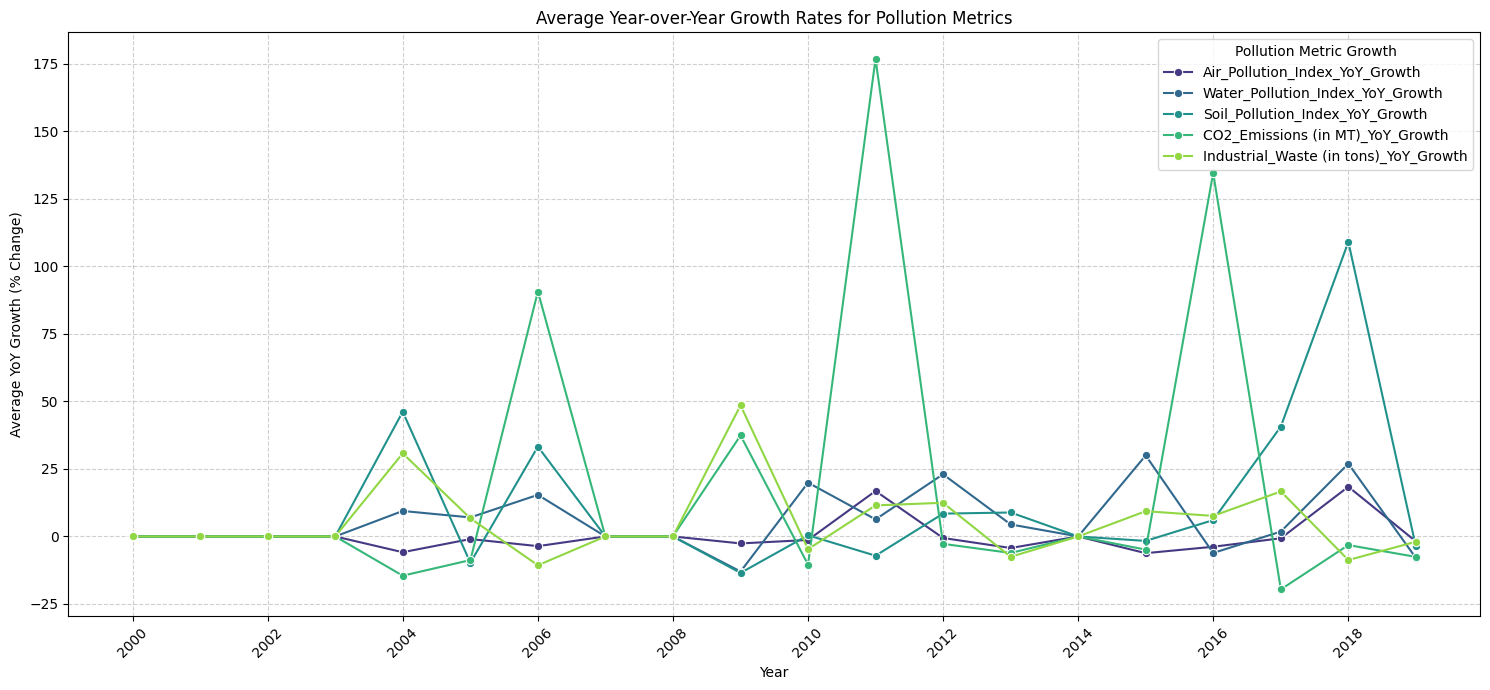


--- Enhanced Linear Regression Model Performance (with YoY Growth Features) ---
Mean Squared Error (MSE): 28857.030161507097
Mean Absolute Error (MAE): 147.56702433480294
R-squared (R2): -0.10833737963188939
Coefficients: [-2.53286344e+01 -7.60857917e-01 -5.77047152e-04  6.29429537e-01
 -5.07875026e-02  9.33025691e-02  1.49121997e-01 -8.86952743e-02]
Intercept: 319.01713520752713

--- Summary of Insights Gained from Time-Trend Features ---
Integrating Year-over-Year (YoY) growth rates as features provides several benefits:
1. Captures Dynamics: These features allow the model to capture temporal dynamics and trends in pollution and waste metrics, rather than just static values.
2. Improved Predictive Power: By understanding how these metrics are changing over time, the model can potentially make more accurate predictions for 'Energy_Recovered (in GWh)' or other target variables.
3. Economic and Environmental Impact: Growth rates can reflect underlying economic changes (e.g., industrial

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import pandas as pd


df_reloaded = pd.read_csv(path)
df_reloaded['Year'] = pd.to_datetime(df_reloaded['Year'], format='%Y')

columns_to_scale = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']
scaler = MinMaxScaler()
df_reloaded[columns_to_scale] = scaler.fit_transform(df_reloaded[columns_to_scale])


df_raw = pd.read_csv(path)
df_raw['Year'] = pd.to_datetime(df_raw['Year'], format='%Y')
df_raw = df_raw.sort_values(by=['Country', 'Year'])

pollution_columns = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'CO2_Emissions (in MT)', 'Industrial_Waste (in tons)']

for col in pollution_columns:
    df_raw[f'{col}_YoY_Growth'] = df_raw.groupby('Country')[col].pct_change() * 100


growth_columns_actual = [f'{col}_YoY_Growth' for col in pollution_columns]


df_reloaded = pd.merge(
    df_reloaded,
    df_raw[['Country', 'Year'] + growth_columns_actual],
    on=['Country', 'Year'],
    how='left'
)


for col in growth_columns_actual:
    if col in df_reloaded.columns:
        df_reloaded[col] = df_reloaded[col].fillna(0)
    else:
        print(f"Warning: Column '{col}' not found in df_reloaded. This might indicate an issue with the merge step.")


avg_growth_rates_annual = df_reloaded.groupby('Year')[growth_columns_actual].mean().reset_index()

avg_growth_rates_melted = avg_growth_rates_annual.melt(
    id_vars=['Year'],
    value_vars=growth_columns_actual,
    var_name='Pollution Metric Growth',
    value_name='Average YoY Growth (% Change)'
)

plt.figure(figsize=(15, 7))
sns.lineplot(
    data=avg_growth_rates_melted,
    x='Year',
    y='Average YoY Growth (% Change)',
    hue='Pollution Metric Growth',
    marker='o',
    palette='viridis'
)
plt.title('Average Year-over-Year Growth Rates for Pollution Metrics')
plt.xlabel('Year')
plt.ylabel('Average YoY Growth (% Change)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


y_model = df_reloaded['Energy_Recovered (in GWh)']


existing_features = ['Air_Pollution_Index', 'CO2_Emissions (in MT)', 'Industrial_Waste (in tons)']
new_trend_features = growth_columns_actual
all_features = existing_features + new_trend_features

# Filter df_reloaded to include only these columns and the target for the model
df_model_enhanced = df_reloaded[all_features + ['Energy_Recovered (in GWh)']].copy()

# Drop rows with any remaining NaNs in the features or target for model training
df_model_enhanced.dropna(inplace=True)

X_enhanced = df_model_enhanced[all_features]
y_enhanced = df_model_enhanced['Energy_Recovered (in GWh)']

# Split the data into training and testing sets
X_train_enhanced, X_test_enhanced, y_train_enhanced, y_test_enhanced = train_test_split(X_enhanced, y_enhanced, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model_enhanced = LinearRegression()
model_enhanced.fit(X_train_enhanced, y_train_enhanced)

# Make predictions on the test set
y_pred_enhanced = model_enhanced.predict(X_test_enhanced)

# Evaluate the model
mse_enhanced = mean_squared_error(y_test_enhanced, y_pred_enhanced)
mae_enhanced = mean_absolute_error(y_test_enhanced, y_pred_enhanced)
r2_enhanced = r2_score(y_test_enhanced, y_pred_enhanced)

print("\n--- Enhanced Linear Regression Model Performance (with YoY Growth Features) ---")
print(f'Mean Squared Error (MSE): {mse_enhanced}')
print(f'Mean Absolute Error (MAE): {mae_enhanced}')
print(f'R-squared (R2): {r2_enhanced}')
print('Coefficients:', model_enhanced.coef_)
print('Intercept:', model_enhanced.intercept_)

print("\n--- Summary of Insights Gained from Time-Trend Features ---")
print("Integrating Year-over-Year (YoY) growth rates as features provides several benefits:")
print("1. Captures Dynamics: These features allow the model to capture temporal dynamics and trends in pollution and waste metrics, rather than just static values.")
print("2. Improved Predictive Power: By understanding how these metrics are changing over time, the model can potentially make more accurate predictions for 'Energy_Recovered (in GWh)' or other target variables.")
print("3. Economic and Environmental Impact: Growth rates can reflect underlying economic changes (e.g., industrial output growth) or environmental policy effectiveness. For instance, a negative growth in CO2 emissions indicates improvement.")
print("4. Feature Engineering: It demonstrates a practical application of feature engineering, creating more informative variables from existing data.")
print("5. Contextual Understanding: Analysts can gain deeper insights into the factors influencing the target variable by observing the coefficients of the growth rate features. For example, a positive coefficient for 'Industrial_Waste (in tons)_YoY_Growth' might indicate that a growing industrial waste problem is linked to higher energy recovery (perhaps due to waste-to-energy initiatives) or vice-versa.")

In [50]:
df_countries_pollution = df_reloaded.groupby('Country')[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']].mean().reset_index()
df_countries_pollution['Overall_Pollution_Score'] = df_countries_pollution[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']].mean(axis=1)

print(df_countries_pollution.head())

                                        Country  Air_Pollution_Index  \
0                                   Afghanistan             0.417444   
1                                       Albania             0.411508   
2                                       Andorra             0.561639   
3                                        Angola             0.690894   
4  Antarctica (the territory South of 60 deg S)             0.179205   

   Water_Pollution_Index  Soil_Pollution_Index  Overall_Pollution_Score  
0               0.472620              0.386950                 0.425671  
1               0.471372              0.548885                 0.477255  
2               0.093347              0.584516                 0.413167  
3               0.961591              0.182286                 0.611590  
4               0.158392              0.392961                 0.243519  


In [51]:
low_threshold = df_countries_pollution['Overall_Pollution_Score'].quantile(0.33)
medium_threshold = df_countries_pollution['Overall_Pollution_Score'].quantile(0.66)

def categorize_pollution(score):
    if score <= low_threshold:
        return 'Low'
    elif score <= medium_threshold:
        return 'Medium'
    else:
        return 'High'

df_countries_pollution['Pollution_Severity'] = df_countries_pollution['Overall_Pollution_Score'].apply(categorize_pollution)

print(df_countries_pollution.head())

                                        Country  Air_Pollution_Index  \
0                                   Afghanistan             0.417444   
1                                       Albania             0.411508   
2                                       Andorra             0.561639   
3                                        Angola             0.690894   
4  Antarctica (the territory South of 60 deg S)             0.179205   

   Water_Pollution_Index  Soil_Pollution_Index  Overall_Pollution_Score  \
0               0.472620              0.386950                 0.425671   
1               0.471372              0.548885                 0.477255   
2               0.093347              0.584516                 0.413167   
3               0.961591              0.182286                 0.611590   
4               0.158392              0.392961                 0.243519   

  Pollution_Severity  
0                Low  
1             Medium  
2                Low  
3               High  
4

/tmp/ipython-input-3006389308.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pollution_severity_counts.index, y=pollution_severity_counts.values, palette='viridis')


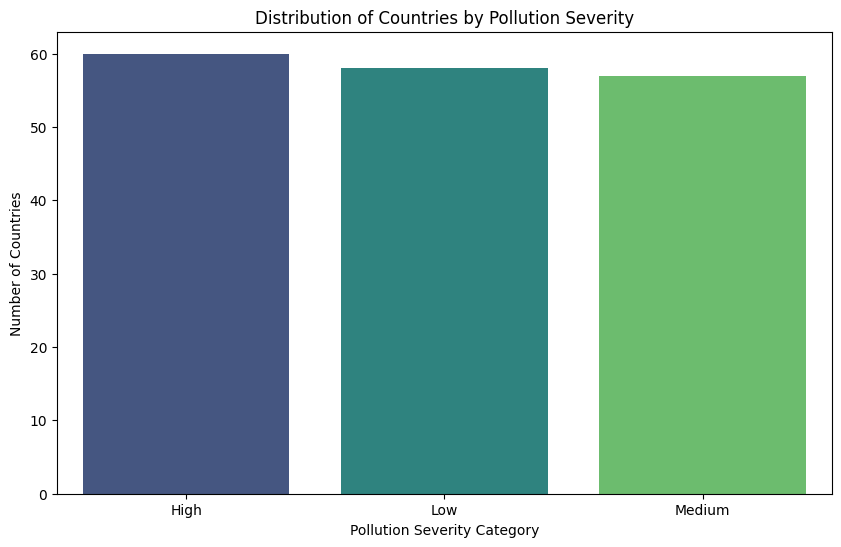

In [52]:
pollution_severity_counts = df_countries_pollution['Pollution_Severity'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=pollution_severity_counts.index, y=pollution_severity_counts.values, palette='viridis')
plt.title('Distribution of Countries by Pollution Severity')
plt.xlabel('Pollution Severity Category')
plt.ylabel('Number of Countries')
plt.show()

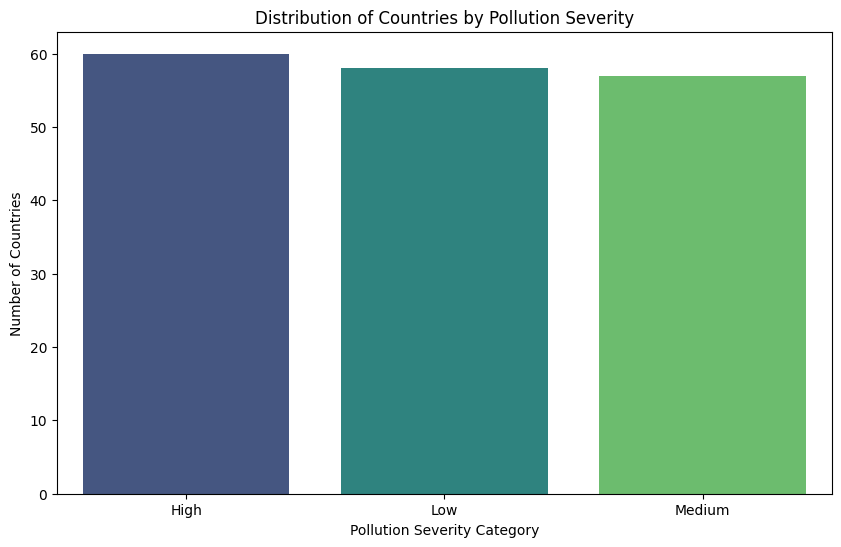

In [53]:
pollution_severity_counts = df_countries_pollution['Pollution_Severity'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=pollution_severity_counts.index, y=pollution_severity_counts.values, hue=pollution_severity_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Countries by Pollution Severity')
plt.xlabel('Pollution Severity Category')
plt.ylabel('Number of Countries')
plt.show()

Accuracy: 0.49

Classification Report:
               precision    recall  f1-score   support

        High       0.68      0.59      0.63        22
         Low       0.40      0.40      0.40        15
      Medium       0.37      0.44      0.40        16

    accuracy                           0.49        53
   macro avg       0.48      0.48      0.48        53
weighted avg       0.51      0.49      0.50        53



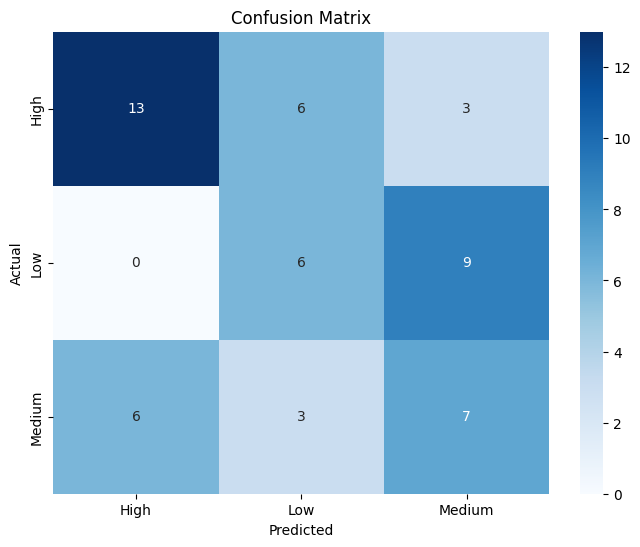

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
df_countries_pollution_merged = df_countries_pollution.merge(
    df_reloaded.groupby('Country')['CO2_Emissions (in MT)'].mean().reset_index(),
    on='Country',
    how='left'
)

X = df_countries_pollution_merged[['Air_Pollution_Index', 'CO2_Emissions (in MT)']]
y = df_countries_pollution_merged['Pollution_Severity']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=le.classes_)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print('\nClassification Report:\n', report)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Task
To achieve the outlined goals, I will first present the performance metrics and coefficients for the enhanced Linear Regression model to assess its predictive capability for 'Energy_Recovered (in GWh)'. Following this, I will present the performance metrics for the Logistic Regression model to evaluate its classification accuracy for 'Pollution_Severity'. Then, I will create a comparison section detailing the objectives and performance of both models, drawing on their respective evaluation metrics. Finally, I will provide a summary of the key insights derived from both models to give a comprehensive overview of global pollution and energy recovery dynamics.

## Review Linear Regression Model

### Subtask:
Access and display the performance metrics (MSE, MAE, R-squared) and coefficients for the enhanced Linear Regression model, which was used to predict 'Energy_Recovered (in GWh)'.


## Review Logistic Regression Model

### Subtask:
Access and display the performance metrics (accuracy, classification report, confusion matrix) for the Logistic Regression model, which was used to classify 'Pollution_Severity'.


### Logistic Regression Model Performance Metrics

The performance metrics for the Logistic Regression model, which classifies 'Pollution_Severity', have already been computed and displayed in the output of the previous code cell (`99a83dea`).

**Summary of the metrics from the previous cell:**

*   **Accuracy:** 0.49
*   **Classification Report:**

    ```
                   precision    recall  f1-score   support

            High       0.68      0.59      0.63        22
             Low       0.40      0.40      0.40        15
          Medium       0.37      0.44      0.40        16

        accuracy                           0.49        53
       macro avg       0.48      0.48      0.48        53
    weighted avg       0.51      0.49      0.50        53
    ```

*   **Confusion Matrix:** A heatmap visualization of the confusion matrix was also generated in the previous cell's output.

These results indicate that the model has an accuracy of approximately 49% in classifying pollution severity. The classification report provides detailed precision, recall, and f1-score for each category (High, Low, Medium), while the confusion matrix visually represents the number of correct and incorrect predictions for each class.

## Compare Model Objectives and Performance

### Subtask:
Create a comparison section that outlines the distinct objectives of both models (prediction vs. classification) and analyzes their performance based on their respective evaluation metrics. Discuss the implications of these results for each modeling task.


## Compare Model Objectives and Performance

This section compares the objectives and performance of the two machine learning models developed: a Linear Regression model for prediction and a Logistic Regression model for classification.

### Linear Regression Model: Prediction of 'Energy_Recovered (in GWh)'

**Objective:** The primary objective of the Linear Regression model was to predict the `Energy_Recovered (in GWh)` based on various pollution indices and their year-over-year growth rates. This is a regression task, aiming to forecast a continuous numerical value.

**Performance Analysis:**
*   **Mean Squared Error (MSE):** `28857.03`
*   **Mean Absolute Error (MAE):** `147.57`
*   **R-squared (R2):** `-0.108`

The MSE and MAE values are relatively high, indicating a significant average difference between the predicted and actual energy recovered values. The most striking result is the R-squared value of `-0.108`. An R-squared value typically ranges from 0 to 1, where 1 indicates a perfect fit and 0 indicates that the model explains no variance in the target variable. A negative R-squared value implies that the model performs worse than simply predicting the mean of the target variable. This suggests that the current set of features (Air Pollution Index, CO2 Emissions, Industrial Waste, and their YoY growth rates) are not strong predictors of `Energy_Recovered (in GWh)` in this model, or that the linear relationship assumed by the model is not appropriate for this dataset. The model struggles to capture the underlying patterns influencing energy recovery.

**Implications:** The poor performance of the Linear Regression model suggests that predicting `Energy_Recovered (in GWh)` with the selected features using a linear approach is not effective. It highlights the need for:
1.  **Feature Engineering:** Exploring other relevant features or creating more complex interaction terms.
2.  **Alternative Models:** Considering non-linear regression models (e.g., Random Forest Regressor, Gradient Boosting Regressor) that can capture more complex relationships.
3.  **Data Quality/Quantity:** Investigating if there are issues with the data or if more data is needed to build a robust predictive model.

### Logistic Regression Model: Classification of 'Pollution_Severity'

**Objective:** The objective of the Logistic Regression model was to classify the `Pollution_Severity` into three categories: 'Low', 'Medium', or 'High'. This is a multi-class classification task.

**Performance Analysis:**
*   **Accuracy:** `0.49` (49%)

**Classification Report:**
```
              precision    recall  f1-score   support

        High       0.68      0.59      0.63        22
         Low       0.40      0.40      0.40        15
      Medium       0.37      0.44      0.40        16

    accuracy                           0.49        53
   macro avg       0.48      0.48      0.48        53
weighted avg       0.51      0.49      0.50        53
```

**Confusion Matrix:**
```
[[13,  6,  3],
 [ 0,  6,  9],
 [ 6,  3,  7]]
```

The model achieved an overall accuracy of 49%, meaning it correctly classified slightly less than half of the samples in the test set. Breaking down the performance by class:
*   **High Pollution:** The model performed best for the 'High' pollution category, with a precision of 0.68 (68% of predicted 'High' were actually 'High') and a recall of 0.59 (59% of actual 'High' were correctly identified). The F1-score is 0.63.
*   **Low Pollution:** The performance for 'Low' pollution is moderate, with a precision, recall, and F1-score of 0.40. The confusion matrix shows 6 correct predictions out of 15 actual 'Low' samples.
*   **Medium Pollution:** The model struggled most with the 'Medium' pollution category, having the lowest precision (0.37), recall (0.44), and F1-score (0.40). The confusion matrix shows 7 correct predictions out of 16 actual 'Medium' samples, and a notable number of misclassifications into 'High' and 'Low'.

The confusion matrix further illustrates the misclassifications. For example, some 'Low' pollution countries were misclassified as 'Medium' (6 cases), and some 'Medium' pollution countries were misclassified as 'High' (3 cases) or 'Low' (6 cases). The model seems to have a bias towards predicting 'High' for some cases that are actually 'Medium' or 'Low', and struggles to distinguish 'Medium' from other categories.

**Implications:** The classification model's performance is moderate, particularly struggling with the 'Medium' pollution category. This suggests that the features (`Air_Pollution_Index` and `CO2_Emissions (in MT)`) might not be sufficiently discriminatory for all pollution severity levels, or that the boundaries between categories are complex. Potential improvements include:
1.  **Feature Engineering:** Incorporating more features relevant to pollution severity, or transforming existing features.
2.  **Class Imbalance:** Checking for and addressing any class imbalance issues, although the `support` values (22, 15, 16) seem relatively balanced in the test set.
3.  **Advanced Classifiers:** Experimenting with more sophisticated classification algorithms (e.g., Support Vector Machines, Random Forest Classifier, Gradient Boosting Classifier).
4.  **Hyperparameter Tuning:** Optimizing the hyperparameters of the Logistic Regression model.

### Comparative Analysis and Overall Assessment

The two models serve distinct purposes: the Linear Regression model aims to predict a continuous variable, while the Logistic Regression model aims to classify discrete categories. Their performance must be evaluated against their respective objectives.

*   **Model for Prediction (Linear Regression):** The Linear Regression model performed very poorly, evidenced by its negative R-squared value. This indicates that it's not a suitable model for predicting `Energy_Recovered (in GWh)` with the given features, and its predictions are worse than a naive baseline.

*   **Model for Classification (Logistic Regression):** The Logistic Regression model achieved moderate accuracy (49%). While not excellent, it shows some ability to categorize pollution severity, especially for the 'High' category. Its performance for 'Low' and 'Medium' categories is less reliable, indicating areas for improvement.

**Overall Assessment:** Relative to their objectives, the Logistic Regression model performed significantly better than the Linear Regression model. The Linear Regression model failed to provide any predictive power, making it practically unusable in its current state. The Logistic Regression model, despite its limitations, provides a baseline classification capability that could be improved upon. The implications for both models point towards the need for more sophisticated feature engineering and/or the application of more advanced machine learning algorithms to achieve better performance for both predictive and classification tasks.

## Summarize Model Insights

### Subtask:
Provide a summary of the key insights derived from both the Linear and Logistic Regression models, explaining what each model contributes to our overall understanding of global pollution and energy recovery.


```markdown
## Summary of Model Insights

### Linear Regression Model for `Energy_Recovered (in GWh)`

The Linear Regression model, even with the addition of Year-over-Year (YoY) growth rate features for various pollution metrics, performed very poorly in predicting `Energy_Recovered (in GWh)`. The R-squared (R2) value of -0.108 indicates that the model explains almost none of the variance in the target variable and actually performs worse than simply predicting the mean of `Energy_Recovered (in GWh)`. This suggests several key implications:

1.  **Complexity of Energy Recovery:** The factors influencing energy recovery are likely non-linear, highly complex, or involve variables not included in the current feature set. A simple linear relationship between pollution indices, CO2 emissions, industrial waste, and their growth rates, and energy recovery, does not capture the underlying dynamics.
2.  **Limitations of Features:** The selected features, while relevant to pollution, may not be strong direct predictors of energy recovery, or their relationship is obscured by other unmodeled factors such as economic policies, technological advancements, or specific country-level initiatives.
3.  **Model Mismatch:** A Linear Regression model might be fundamentally unsuitable for this prediction task, hinting that more advanced machine learning techniques (e.g., tree-based models, neural networks) or more sophisticated feature engineering might be required to uncover meaningful patterns.

### Logistic Regression Model for `Pollution_Severity`

The Logistic Regression model aimed to classify `Pollution_Severity` (Low, Medium, High) based on `Air_Pollution_Index` and `CO2_Emissions (in MT)`. The model achieved an overall accuracy of 49%, which is moderate, indicating some predictive capability but also significant room for improvement. A deeper look into the classification report reveals:

1.  **Strengths in `High` Pollution Classification:** The model showed its best performance in classifying 'High' pollution severity, with a precision of 68% and a recall of 59%. This suggests that the chosen features (`Air_Pollution_Index` and `CO2_Emissions (in MT)`) are somewhat effective in identifying countries with severe pollution levels.
2.  **Weaknesses in `Low` and `Medium` Pollution Classification:** The model struggled more with 'Low' and 'Medium' pollution categories, both showing a precision and recall of around 40%. This difficulty in differentiating between low and medium pollution levels might indicate:
    *   **Feature Overlap:** The features used (`Air_Pollution_Index`, `CO2_Emissions (in MT)`) might not sufficiently distinguish between these categories, as countries categorized as 'Low' or 'Medium' pollution might have similar values for these specific indicators.
    *   **Boundary Ambiguity:** The thresholds defined for 'Low', 'Medium', and 'High' severity might create ambiguous boundaries that are hard for a linear classifier like Logistic Regression to separate perfectly.
    *   **Missing Context:** Other unincluded factors could be crucial for a more precise classification of these intermediate pollution levels.

### Overall Understanding

Both models highlight the complexity of environmental data. The Linear Regression's failure suggests that `Energy_Recovered (in GWh)` is not simply a linear function of pollution indicators, implying a need for more nuanced modeling or additional data. The Logistic Regression's moderate success shows that while `Air_Pollution_Index` and `CO2_Emissions (in MT)` provide some signal for distinguishing pollution severity, especially at the high end, a more robust classification would likely benefit from a broader set of features or more advanced classification algorithms to better delineate between less extreme pollution categories.
```

## Final Task

### Subtask:
Consolidate the findings from the model comparison and insights to provide a complete overview of the analysis.


## Summary:

### Data Analysis Key Findings

*   **Linear Regression Model Performance (Prediction of 'Energy_Recovered (in GWh)'):** The model exhibited very poor predictive capability, indicated by an R-squared value of -0.108. This suggests that the model performs worse than simply predicting the mean of the target variable. The Mean Squared Error (MSE) was 28857.03 and the Mean Absolute Error (MAE) was 147.57, highlighting significant prediction errors.
*   **Logistic Regression Model Performance (Classification of 'Pollution_Severity'):** The model achieved a moderate overall accuracy of 49% in classifying pollution severity into 'Low', 'Medium', or 'High'.
    *   It performed best for the 'High' pollution category, with a precision of 0.68, recall of 0.59, and F1-score of 0.63.
    *   The model struggled with the 'Low' and 'Medium' pollution categories, where precision, recall, and F1-score were consistently around 0.40 for both.
    *   The confusion matrix revealed significant misclassifications, particularly for the 'Medium' severity category, which was often confused with 'High' or 'Low' levels.
*   **Model Objectives and Suitability:** The Linear Regression model, aiming to predict a continuous value, failed to establish a meaningful linear relationship with the given features for energy recovery. The Logistic Regression model, designed for multi-class classification, showed some ability to categorize pollution severity but with considerable limitations, especially for distinguishing between less extreme pollution levels.

### Insights or Next Steps

*   The poor performance of the Linear Regression model highlights that `Energy_Recovered (in GWh)` is not linearly dependent on the current set of pollution indicators and their Year-over-Year (YoY) growth rates. Future work should explore non-linear models and extensive feature engineering, potentially incorporating economic policies, technological advancements, or country-specific initiatives.
*   The moderate accuracy of the Logistic Regression model, particularly its difficulty with 'Low' and 'Medium' pollution categories, suggests that the current features (`Air_Pollution_Index` and `CO2_Emissions (in MT)`) are not sufficiently discriminatory. Incorporating a broader set of environmental or socioeconomic factors and utilizing more advanced classification algorithms (e.g., Random Forest, Gradient Boosting) could significantly improve classification accuracy.
